# Equilíbrio de Nash e Ótimo de Pareto no Transporte Urbano do Distrito Federal
## Análise Computacional de Suporte ao Artigo Científico

**Autor:** Jullyano Lino  
**Instituição:** Centro Universitário Internacional UNINTER  
**Disciplina:** Teoria dos Jogos  
**Data:** 2025

---

### Objetivo e Estrutura do Notebook

Este notebook tem por objetivo produzir **todos os insumos computacionais** — tabelas, figuras, cálculos e relatórios analíticos — que fundamentam o artigo científico submetido em LaTeX.

O jogo modelado é um **jogo estratégico em forma normal de dois jogadores** (Gibbons, 1992):

$$G = \bigl(N,\, \{S_i\}_{i \in N},\, \{u_i\}_{i \in N}\bigr)$$

- **Jogador 1 (Motoristas):** $S_1 = \{\text{TP}, \text{CP}\}$  
- **Jogador 2 (GDF):** $S_2 = \{\text{INV}, \text{PARC}, \text{NÃO}\}$

A análise percorre as seguintes etapas:

1. Definição formal da matriz de payoffs
2. Cálculo algébrico das correspondências de melhor resposta
3. Verificação computacional dos Equilíbrios de Nash (EN) via biblioteca `nashpy`
4. Identificação da Fronteira de Pareto e do Ótimo de Pareto
5. Cálculo do Preço da Anarquia (PoA)
6. Análise de estratégias mistas e visualização dos Equilíbrios de Nash Mistos
7. Geração de figuras prontas para o artigo (300 dpi, fontes LaTeX-compatíveis)
8. Relatório textual consolidado

**Referências principais:**  
NASH, J. F. Equilibrium points in *N*-person games. *PNAS*, v. 36, n. 1, p. 48–49, 1950.  
GIBBONS, R. *Game Theory for Applied Economists*. Princeton: Princeton University Press, 1992.  
FIANI, R. *Teoria dos Jogos*. Rio de Janeiro: Elsevier, 2004.  
BIERMAN, H. S.; FERNANDEZ, L. F. *Teoria dos Jogos*. 2. ed. São Paulo: Pearson, 2011.

---
## Célula 1 — Importações e Configuração Global

In [1]:
# ============================================================
# CÉLULA 1 — Importações e configuração global
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.gridspec import GridSpec
from scipy.spatial import ConvexHull
import nashpy as nash
import itertools
import os

# ── Diretório de saída para figuras ──────────────────────────
OUTPUT_DIR = "figuras_artigo"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Estilo global dos gráficos ───────────────────────────────
plt.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['DejaVu Serif', 'Times New Roman', 'Georgia'],
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'legend.fontsize':    10,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'figure.dpi':         150,
    'savefig.dpi':        300,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.35,
    'grid.linestyle':     '--',
})

# ── Paleta de cores ──────────────────────────────────────────
COR_NASH   = '#D7263D'   # vermelho — EN
COR_PARETO = '#2E86AB'   # azul — Pareto-ótimo
COR_EMPIR  = '#F4A261'   # laranja — equilíbrio empírico
COR_DOMINA = '#B5B5B5'   # cinza — dominado
COR_FUNDO  = '#F9F9F9'

print("✓ Ambiente configurado com sucesso.")
print(f"  nashpy  : {nash.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  pandas  : {pd.__version__}")
print(f"  Saída   : ./{OUTPUT_DIR}/")

✓ Ambiente configurado com sucesso.
  nashpy  : 0.0.43
  numpy   : 2.4.4
  pandas  : 3.0.2
  Saída   : ./figuras_artigo/


---
## Célula 2 — Definição Formal do Jogo em Forma Normal

In [2]:
# ============================================================
# CÉLULA 2 — Definição do jogo G em forma normal
# ============================================================
#
# G = (N, {S_i}, {u_i}),  N = {1, 2}
#
# Jogador 1 (linhas)  — Motoristas
#   S_1 = {TP, CP}
#
# Jogador 2 (colunas) — GDF
#   S_2 = {INV, PARC, NÃO}
#
# Payoffs: escala ordinal  {1, 2, 3, 4},  maior = melhor.
#
# A1[i, j]  = u_1(s_i, s_j)   (Motoristas)
# A2[i, j]  = u_2(s_i, s_j)   (GDF)
#
#            INV   PARC   NÃO
# TP    =>  (4,4) (3,3)  (1,2)
# CP    =>  (2,3) (2,2)  (1,1)
# ============================================================

# Rótulos
S1 = ['TP', 'CP']
S2 = ['INV', 'PARC', 'NÃO']

# Matrizes de payoffs
A1 = np.array([
    [4, 3, 1],   # TP
    [2, 2, 1],   # CP
], dtype=float)

A2 = np.array([
    [4, 3, 2],   # TP
    [3, 2, 1],   # CP
], dtype=float)

# Conjunto de perfis
perfis = list(itertools.product(S1, S2))

# Vetores de payoff para cada perfil
payoffs = {
    (s1, s2): (A1[i, j], A2[i, j])
    for i, s1 in enumerate(S1)
    for j, s2 in enumerate(S2)
}

# ── Exibição da bimatriz ─────────────────────────────────────
idx_linhas = pd.MultiIndex.from_tuples([('Jogador 1 — Motoristas', s) for s in S1])
idx_cols   = pd.MultiIndex.from_tuples([('Jogador 2 — GDF', s) for s in S2])

data_display = [
    [f"({int(A1[i,j])}, {int(A2[i,j])})" for j in range(len(S2))]
    for i in range(len(S1))
]

df_bimatriz = pd.DataFrame(data_display, index=idx_linhas, columns=idx_cols)

print("=" * 60)
print("BIMATRIZ DO JOGO  G = (N, {S_i}, {u_i})")
print("Formato das células: (u_1, u_2)")
print("=" * 60)
print(df_bimatriz.to_string())
print()
print("Cardinalidade do espaço de perfis:  |S| =", len(perfis))
print("Perfis:", perfis)

BIMATRIZ DO JOGO  G = (N, {S_i}, {u_i})
Formato das células: (u_1, u_2)
                          Jogador 2 — GDF                
                                      INV    PARC     NÃO
Jogador 1 — Motoristas TP          (4, 4)  (3, 3)  (1, 2)
                       CP          (2, 3)  (2, 2)  (1, 1)

Cardinalidade do espaço de perfis:  |S| = 6
Perfis: [('TP', 'INV'), ('TP', 'PARC'), ('TP', 'NÃO'), ('CP', 'INV'), ('CP', 'PARC'), ('CP', 'NÃO')]


---
## Célula 3 — Correspondências de Melhor Resposta (Cálculo Algébrico)

In [3]:
# ============================================================
# CÉLULA 3 — Cálculo explícito das correspondências de
#             melhor resposta BR_1 e BR_2
# ============================================================
#
# Definição (Gibbons, 1992, p. 8):
#
#   BR_i(s_{-i}) = argmax_{s_i in S_i}  u_i(s_i, s_{-i})
#
# ============================================================

def melhor_resposta(payoff_matrix, strategies, axis):
    """
    Calcula a correspondência de melhor resposta.

    Parâmetros
    ----------
    payoff_matrix : np.ndarray  (shape n_linhas x n_colunas)
        Matriz de payoffs do jogador que está otimizando.
    strategies    : list
        Rótulos do jogador que está otimizando.
    axis          : int
        0  → o jogador 1 (linhas) otimiza dado s_2 (colunas fixas)
        1  → o jogador 2 (colunas) otimiza dado s_1 (linhas fixas)

    Retorno
    -------
    dict : {estratégia_oponente -> [melhor(es) resposta(s)]}
    """
    br = {}
    if axis == 0:   # jogador 1 otimiza; s_2 indexa colunas
        opp_labels = S2
        for j, s2 in enumerate(opp_labels):
            coluna = payoff_matrix[:, j]
            max_val = coluna.max()
            br[s2] = [strategies[i] for i, v in enumerate(coluna) if v == max_val]
    else:           # jogador 2 otimiza; s_1 indexa linhas
        opp_labels = S1
        for i, s1 in enumerate(opp_labels):
            linha = payoff_matrix[i, :]
            max_val = linha.max()
            br[s1] = [S2[j] for j, v in enumerate(linha) if v == max_val]
    return br


BR1 = melhor_resposta(A1, S1, axis=0)
BR2 = melhor_resposta(A2, S2, axis=1)

# ── Relatório das melhores respostas ─────────────────────────
print("=" * 60)
print("CORRESPONDÊNCIAS DE MELHOR RESPOSTA")
print("=" * 60)
print()
print("BR_1(s_2)  —  Motoristas:")
for s2, br in BR1.items():
    payoffs_col = {s1: A1[i, S2.index(s2)] for i, s1 in enumerate(S1)}
    print(f"  BR_1({s2:<6}) = {br}")
    print(f"           payoffs: {payoffs_col}")
    print(f"           argmax  = {br}")
    print()

print("BR_2(s_1)  —  GDF:")
for s1, br in BR2.items():
    payoffs_row = {s2: A2[S1.index(s1), j] for j, s2 in enumerate(S2)}
    print(f"  BR_2({s1:<6}) = {br}")
    print(f"           payoffs: {payoffs_row}")
    print(f"           argmax  = {br}")
    print()

CORRESPONDÊNCIAS DE MELHOR RESPOSTA

BR_1(s_2)  —  Motoristas:
  BR_1(INV   ) = ['TP']
           payoffs: {'TP': np.float64(4.0), 'CP': np.float64(2.0)}
           argmax  = ['TP']

  BR_1(PARC  ) = ['TP']
           payoffs: {'TP': np.float64(3.0), 'CP': np.float64(2.0)}
           argmax  = ['TP']

  BR_1(NÃO   ) = ['TP', 'CP']
           payoffs: {'TP': np.float64(1.0), 'CP': np.float64(1.0)}
           argmax  = ['TP', 'CP']

BR_2(s_1)  —  GDF:
  BR_2(TP    ) = ['INV']
           payoffs: {'INV': np.float64(4.0), 'PARC': np.float64(3.0), 'NÃO': np.float64(2.0)}
           argmax  = ['INV']

  BR_2(CP    ) = ['INV']
           payoffs: {'INV': np.float64(3.0), 'PARC': np.float64(2.0), 'NÃO': np.float64(1.0)}
           argmax  = ['INV']



---
## Célula 4 — Identificação dos Equilíbrios de Nash em Estratégias Puras

In [4]:
# ============================================================
# CÉLULA 4 — Identificação dos Equilíbrios de Nash (EN)
#             em estratégias puras
# ============================================================
#
# Definição (Nash, 1950; Gibbons, 1992):
#
#   s* = (s_1*, s_2*) é EN sse:
#     s_1* ∈ BR_1(s_2*)   E   s_2* ∈ BR_2(s_1*)
#
# Verificamos todos os |S| = 6 perfis.
# ============================================================

def verificar_nash_puro(A1, A2, S1, S2, BR1, BR2):
    """
    Verifica, para cada perfil (s1, s2), se é Equilíbrio de Nash.

    Retorna lista de tuplas: (s1, s2, é_EN, u1, u2, obs)
    """
    resultados = []
    for i, s1 in enumerate(S1):
        for j, s2 in enumerate(S2):
            cond1 = s1 in BR1[s2]   # s1 é melhor resposta do J1 a s2
            cond2 = s2 in BR2[s1]   # s2 é melhor resposta do J2 a s1
            en    = cond1 and cond2
            u1    = int(A1[i, j])
            u2    = int(A2[i, j])
            obs   = ""
            if not cond1:
                obs += f"{s1} ∉ BR_1({s2})={BR1[s2]}  "
            if not cond2:
                obs += f"{s2} ∉ BR_2({s1})={BR2[s1]}"
            resultados.append((s1, s2, en, u1, u2, obs.strip()))
    return resultados


resultados_EN = verificar_nash_puro(A1, A2, S1, S2, BR1, BR2)

# ── Verificação cruzada com nashpy ───────────────────────────
jogo_nashpy = nash.Game(A1, A2)
equilibrios_nashpy = list(jogo_nashpy.support_enumeration())

# ── Relatório ────────────────────────────────────────────────
print("=" * 70)
print("VERIFICAÇÃO DOS EQUILÍBRIOS DE NASH — ESTRATÉGIAS PURAS")
print("=" * 70)
print(f"{'Perfil':<20} {'u1':>4} {'u2':>4}  {'É EN?':<8}  Justificativa")
print("-" * 70)

nash_puros = []
for s1, s2, en, u1, u2, obs in resultados_EN:
    sinal  = "✓  SIM" if en else "✗  NÃO"
    justi  = "s1* ∈ BR_1(s2*) ∧ s2* ∈ BR_2(s1*)" if en else obs
    print(f"({s1}, {s2}){'':>{12-len(s1)-len(s2)}}  {u1:>4} {u2:>4}  {sinal:<8}  {justi}")
    if en:
        nash_puros.append((s1, s2, u1, u2))

print("-" * 70)
print(f"\nTotal de EN em estratégias puras: {len(nash_puros)}")
for s1, s2, u1, u2 in nash_puros:
    print(f"  → ({s1}, {s2})  com payoff ({u1}, {u2})")

print()
print("Verificação cruzada com nashpy (support enumeration):")
for sigma1, sigma2 in equilibrios_nashpy:
    idx1 = np.where(sigma1 > 1e-10)[0]
    idx2 = np.where(sigma2 > 1e-10)[0]
    s1_str = "+".join(f"{sigma1[k]:.3f}·{S1[k]}" for k in idx1)
    s2_str = "+".join(f"{sigma2[k]:.3f}·{S2[k]}" for k in idx2)
    print(f"  σ_1 = [{s1_str}]   σ_2 = [{s2_str}]")

VERIFICAÇÃO DOS EQUILÍBRIOS DE NASH — ESTRATÉGIAS PURAS
Perfil                 u1   u2  É EN?     Justificativa
----------------------------------------------------------------------
(TP, INV)            4    4  ✓  SIM    s1* ∈ BR_1(s2*) ∧ s2* ∈ BR_2(s1*)
(TP, PARC)           3    3  ✗  NÃO    PARC ∉ BR_2(TP)=['INV']
(TP, NÃO)            1    2  ✗  NÃO    NÃO ∉ BR_2(TP)=['INV']
(CP, INV)            2    3  ✗  NÃO    CP ∉ BR_1(INV)=['TP']
(CP, PARC)           2    2  ✗  NÃO    CP ∉ BR_1(PARC)=['TP']  PARC ∉ BR_2(CP)=['INV']
(CP, NÃO)            1    1  ✗  NÃO    NÃO ∉ BR_2(CP)=['INV']
----------------------------------------------------------------------

Total de EN em estratégias puras: 1
  → (TP, INV)  com payoff (4, 4)

Verificação cruzada com nashpy (support enumeration):
  σ_1 = [1.000·TP]   σ_2 = [1.000·INV]


---
## Célula 5 — Análise da Fronteira de Pareto e Dominância

In [5]:
# ============================================================
# CÉLULA 5 — Fronteira de Pareto e Dominância de Pareto
# ============================================================
#
# Definição (Fiani, 2004):
#
#   s Pareto-domina s'  sse
#     u_i(s) ≥ u_i(s') para todo i ∈ N,  e
#     u_i(s) > u_i(s') para algum  i ∈ N.
#
#   s é Pareto-ótimo sse não existe s' que Pareto-domine s.
# ============================================================

def pareto_domina(u_a, u_b):
    """
    Retorna True se o vetor de payoff u_a Pareto-domina u_b.
    u_a, u_b : tuplas (u1, u2)
    """
    return all(a >= b for a, b in zip(u_a, u_b)) and any(a > b for a, b in zip(u_a, u_b))


def fronteira_pareto(payoffs_dict):
    """
    Identifica perfis Pareto-ótimos (não dominados).
    Retorna dicionário {perfil: (u1, u2)} com os ótimos.
    """
    otimos = {}
    for perfil_a, u_a in payoffs_dict.items():
        dominado = any(
            pareto_domina(u_b, u_a)
            for perfil_b, u_b in payoffs_dict.items()
            if perfil_b != perfil_a
        )
        if not dominado:
            otimos[perfil_a] = u_a
    return otimos


pareto_otimos  = fronteira_pareto(payoffs)

# ── Tabela completa de dominância ────────────────────────────
linhas = []
for (s1, s2), (u1, u2) in payoffs.items():
    otimo = (s1, s2) in pareto_otimos
    dominadores = [
        f"({pa},{pb})" for (pa, pb), ub in payoffs.items()
        if pareto_domina(ub, (u1, u2))
    ]
    linhas.append({
        'Perfil': f"({s1}, {s2})",
        'u₁': u1, 'u₂': u2,
        'Soma': u1 + u2,
        'Pareto-ótimo': 'Sim ✓' if otimo else 'Não',
        'Dominado por': ', '.join(dominadores) if dominadores else '—'
    })

df_pareto = pd.DataFrame(linhas).sort_values('Soma', ascending=False)

print("=" * 75)
print("ANÁLISE DA FRONTEIRA DE PARETO")
print("=" * 75)
print(df_pareto.to_string(index=False))
print()
print("Perfis Pareto-ótimos:")
for p, u in pareto_otimos.items():
    print(f"  {p}  →  u = {u}")

# ── Cálculo do Preço da Anarquia (PoA) ───────────────────────
welfare_opt  = max(u1 + u2 for (u1, u2) in payoffs.values())
welfare_nash = sum(payoffs[nash_puros[0][0], nash_puros[0][1]])  if nash_puros else None

# equilíbrio empírico observado no DF
welfare_empirico = sum(payoffs[('CP', 'PARC')])

PoA_formal  = welfare_opt / welfare_nash   if welfare_nash else None
PoA_empirico = welfare_opt / welfare_empirico

print()
print("=" * 50)
print("PREÇO DA ANARQUIA (Price of Anarchy — PoA)")
print("=" * 50)
print(f"  Bem-estar no Ótimo de Pareto (INV, TP)  = {welfare_opt}")
print(f"  Bem-estar no EN formal       (TP, INV)  = {welfare_nash}")
print(f"  Bem-estar no eq. empírico    (CP, PARC) = {welfare_empirico}")
print()
if PoA_formal:
    print(f"  PoA (EN formal  → Ótimo)   = {welfare_opt}/{welfare_nash} = {PoA_formal:.4f}")
print(f"  PoA (eq. empírico → Ótimo) = {welfare_opt}/{welfare_empirico} = {PoA_empirico:.4f}")
print(f"  Perda de bem-estar (empírico vs. ótimo) = {(1 - 1/PoA_empirico)*100:.1f}%")

ANÁLISE DA FRONTEIRA DE PARETO
    Perfil  u₁  u₂  Soma Pareto-ótimo                                       Dominado por
 (TP, INV) 4.0 4.0   8.0        Sim ✓                                                  —
(TP, PARC) 3.0 3.0   6.0          Não                                           (TP,INV)
 (CP, INV) 2.0 3.0   5.0          Não                                (TP,INV), (TP,PARC)
(CP, PARC) 2.0 2.0   4.0          Não                      (TP,INV), (TP,PARC), (CP,INV)
 (TP, NÃO) 1.0 2.0   3.0          Não           (TP,INV), (TP,PARC), (CP,INV), (CP,PARC)
 (CP, NÃO) 1.0 1.0   2.0          Não (TP,INV), (TP,PARC), (TP,NÃO), (CP,INV), (CP,PARC)

Perfis Pareto-ótimos:
  ('TP', 'INV')  →  u = (np.float64(4.0), np.float64(4.0))

PREÇO DA ANARQUIA (Price of Anarchy — PoA)
  Bem-estar no Ótimo de Pareto (INV, TP)  = 8.0
  Bem-estar no EN formal       (TP, INV)  = 8.0
  Bem-estar no eq. empírico    (CP, PARC) = 4.0

  PoA (EN formal  → Ótimo)   = 8.0/8.0 = 1.0000
  PoA (eq. empírico → Ótimo

---
## Célula 6 — Figura 1: Bimatriz Anotada com EN e Ótimo de Pareto

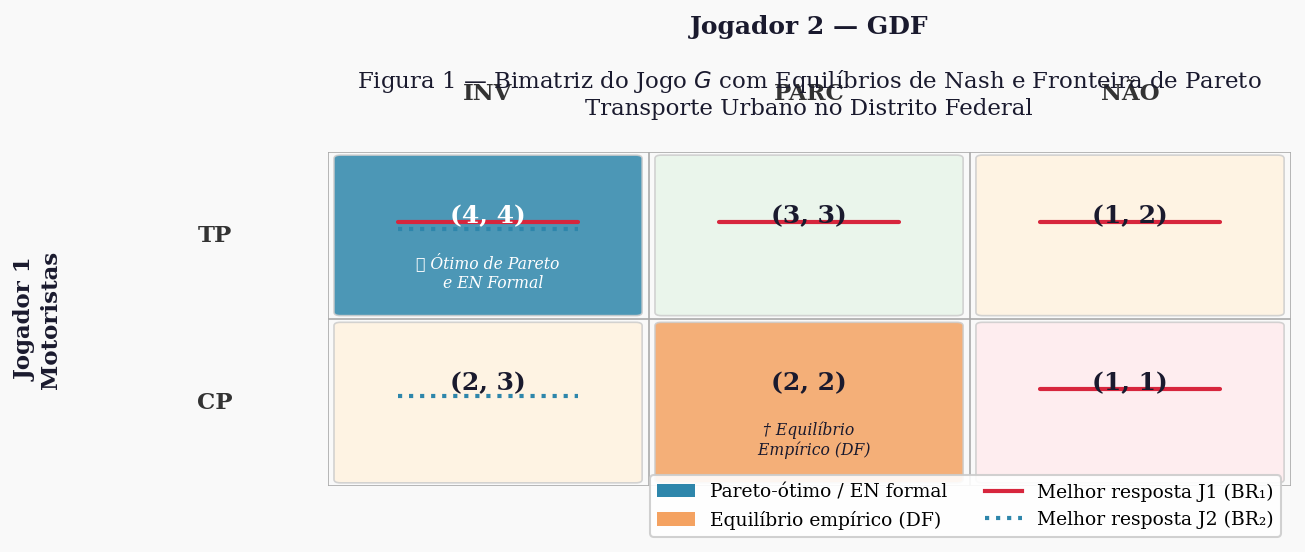

✓ Figura 1 salva em: figuras_artigo/fig1_bimatriz_anotada.png


In [6]:
# ============================================================
# CÉLULA 6 — Figura 1: Bimatriz visual anotada
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 3)
ax.set_ylim(0, 2)
ax.axis('off')
ax.set_facecolor(COR_FUNDO)
fig.patch.set_facecolor(COR_FUNDO)

# ── Grade ────────────────────────────────────────────────────
for x in range(4):
    ax.axvline(x, color='#AAAAAA', lw=0.8)
for y in range(3):
    ax.axhline(y, color='#AAAAAA', lw=0.8)

# ── Cabeçalho GDF (colunas) ───────────────────────────────────
col_labels = ['INV', 'PARC', 'NÃO']
for j, label in enumerate(col_labels):
    ax.text(j + 0.5, 2.35, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='#333333')

ax.text(1.5, 2.75, 'Jogador 2 — GDF', ha='center', va='center',
        fontsize=12, fontweight='bold', color='#1A1A2E')

# ── Cabeçalho Motoristas (linhas) ─────────────────────────────
row_labels = ['TP', 'CP']
for i, label in enumerate(row_labels):
    ax.text(-0.35, 1.5 - i, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='#333333')

ax.text(-0.9, 1.0, 'Jogador 1\nMotoristas', ha='center', va='center',
        fontsize=11, fontweight='bold', color='#1A1A2E', rotation=90)

# ── Células com payoffs e anotações ──────────────────────────
# Mapeamento: (i_linha, j_col) → cor de fundo
anotacoes = {
    (0, 0): ('(4, 4)', COR_PARETO, '★ Ótimo de Pareto\n  e EN Formal'),
    (0, 1): ('(3, 3)', '#E8F5E9', ''),
    (0, 2): ('(1, 2)', '#FFF3E0', ''),
    (1, 0): ('(2, 3)', '#FFF3E0', ''),
    (1, 1): ('(2, 2)', COR_EMPIR, '† Equilíbrio\n  Empírico (DF)'),
    (1, 2): ('(1, 1)', '#FFEBEE', ''),
}

for (i, j), (texto, cor, nota) in anotacoes.items():
    x0, y0 = j, 1 - i
    rect = FancyBboxPatch((x0 + 0.04, y0 + 0.04), 0.92, 0.92,
                          boxstyle="round,pad=0.02",
                          facecolor=cor, edgecolor='#CCCCCC', lw=0.8,
                          alpha=0.85)
    ax.add_patch(rect)

    # payoff
    cor_texto = 'white' if cor in [COR_PARETO] else '#1A1A2E'
    ax.text(x0 + 0.5, y0 + 0.62, texto,
            ha='center', va='center', fontsize=12,
            fontweight='bold', color=cor_texto)

    # anotação
    if nota:
        ax.text(x0 + 0.5, y0 + 0.28, nota,
                ha='center', va='center', fontsize=7.5,
                color=cor_texto, style='italic')

# Marcadores de melhor resposta (sublinhado dos payoffs)
# BR_1: sublinhar u1 máximo por coluna
for j in range(3):
    col_u1 = A1[:, j]
    max_u1 = col_u1.max()
    for i in range(2):
        if A1[i, j] == max_u1:
            x0, y0 = j, 1 - i
            ax.plot([x0 + 0.22, x0 + 0.78], [y0 + 0.58, y0 + 0.58],
                    color='#D7263D', lw=2.0, solid_capstyle='round',
                    label='BR_1' if (i == 0 and j == 0) else '')

# BR_2: sublinhar u2 máximo por linha (linha pontilhada)
for i in range(2):
    row_u2 = A2[i, :]
    max_u2 = row_u2.max()
    for j in range(3):
        if A2[i, j] == max_u2:
            x0, y0 = j, 1 - i
            ax.plot([x0 + 0.22, x0 + 0.78], [y0 + 0.54, y0 + 0.54],
                    color='#2E86AB', lw=2.0, linestyle='dotted',
                    solid_capstyle='round',
                    label='BR_2' if (i == 0 and j == 0) else '')

# ── Legenda ───────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor=COR_PARETO, label='Pareto-ótimo / EN formal'),
    mpatches.Patch(facecolor=COR_EMPIR,  label='Equilíbrio empírico (DF)'),
    plt.Line2D([0], [0], color='#D7263D', lw=2, label='Melhor resposta J1 (BR₁)'),
    plt.Line2D([0], [0], color='#2E86AB', lw=2, ls='dotted', label='Melhor resposta J2 (BR₂)'),
]
ax.legend(handles=legend_elements, loc='lower right',
          bbox_to_anchor=(1.0, -0.18), ncol=2,
          fontsize=9, framealpha=0.9)

ax.set_title(
    'Figura 1 — Bimatriz do Jogo $G$ com Equilíbrios de Nash e Fronteira de Pareto\n'
    'Transporte Urbano no Distrito Federal',
    fontsize=11, pad=18, color='#1A1A2E'
)

plt.tight_layout()
caminho_fig1 = f"{OUTPUT_DIR}/fig1_bimatriz_anotada.png"
plt.savefig(caminho_fig1, dpi=300, bbox_inches='tight',
            facecolor=COR_FUNDO)
plt.show()
print(f"✓ Figura 1 salva em: {caminho_fig1}")

---
## Célula 7 — Figura 2: Espaço de Payoffs, EN, Pareto-ótimo e PoA

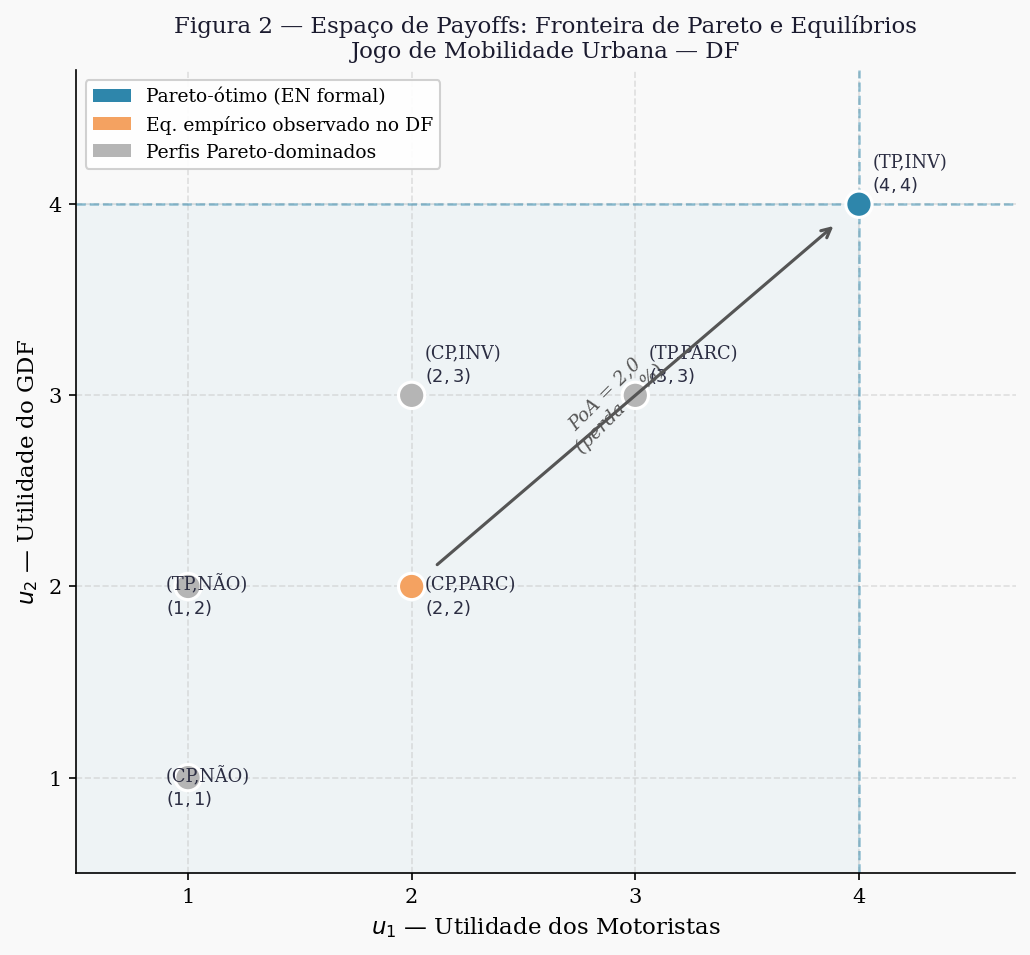

✓ Figura 2 salva em: figuras_artigo/fig2_espaco_payoffs_pareto.png


In [7]:
# ============================================================
# CÉLULA 7 — Figura 2: Espaço de payoffs com fronteira de
#             Pareto, EN, equilíbrio empírico e PoA
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.set_facecolor(COR_FUNDO)
fig.patch.set_facecolor(COR_FUNDO)

# ── Todos os pontos de payoff ─────────────────────────────────
pontos = [(u1, u2, f"({s1},{s2})") for (s1, s2), (u1, u2) in payoffs.items()]
coords_u1 = np.array([p[0] for p in pontos])
coords_u2 = np.array([p[1] for p in pontos])

# ── Fronteira de Pareto (borda superior-direita do conjunto viável) ──
# Construímos ordenando por u1 e filtrando os Pareto-ótimos
pareto_pts = sorted(pareto_otimos.values(), key=lambda x: x[0])

# Coloração dos pontos
cores_pontos = []
for s1, s2 in itertools.product(S1, S2):
    if (s1, s2) in pareto_otimos:
        cores_pontos.append(COR_PARETO)
    elif (s1, s2) == ('CP', 'PARC'):
        cores_pontos.append(COR_EMPIR)
    else:
        cores_pontos.append(COR_DOMINA)

# Scatter
scatter = ax.scatter(coords_u1, coords_u2,
                     c=cores_pontos, s=160, zorder=5,
                     edgecolors='white', linewidths=1.5)

# Rótulos dos pontos
offsets = {
    ('TP', 'INV'):  ( 0.06,  0.07),
    ('TP', 'PARC'): ( 0.06,  0.07),
    ('TP', 'NÃO'):  (-0.10, -0.14),
    ('CP', 'INV'):  ( 0.06,  0.07),
    ('CP', 'PARC'): ( 0.06, -0.14),
    ('CP', 'NÃO'):  (-0.10, -0.14),
}
for s1, s2 in itertools.product(S1, S2):
    u1, u2 = payoffs[(s1, s2)]
    dx, dy = offsets.get((s1, s2), (0.06, 0.07))
    rotulo = f"({s1},{s2})\n$({int(u1)},{int(u2)})$"
    ax.annotate(rotulo, xy=(u1, u2),
                xytext=(u1 + dx, u2 + dy),
                fontsize=8.5, color='#2B2D42', zorder=6)

# ── Fronteira de Pareto: linha superior ───────────────────────
# Para este jogo há apenas 1 ponto Pareto-ótimo (4,4)
# Desenhamos a "curva de indiferença" que passa pelo ponto e
# separa os pontos dominados dos não dominados.
u1_fp = np.array([p[0] for p in pareto_pts])
u2_fp = np.array([p[1] for p in pareto_pts])

# Linha pontilhada marcando o "norte" e "leste" do ponto ótimo
ax.axvline(4, color=COR_PARETO, lw=1.2, ls='--', alpha=0.5)
ax.axhline(4, color=COR_PARETO, lw=1.2, ls='--', alpha=0.5)

# Preenchimento da região Pareto-dominada (abaixo e à esquerda do ótimo)
ax.fill_betweenx([0.5, 4], 0.5, 4,
                 alpha=0.05, color=COR_PARETO, label='Região dominada')

# ── Vetor de melhoria social (empírico → ótimo) ───────────────
ax.annotate(
    '', xy=(3.9, 3.9), xytext=(2.1, 2.1),
    arrowprops=dict(
        arrowstyle='->', color='#555555',
        lw=1.5, connectionstyle='arc3,rad=0.0'
    ), zorder=7
)
ax.text(2.9, 2.7, 'PoA = 2,0\n(perda 50%)',
        fontsize=9, color='#555555', ha='center',
        style='italic', rotation=45)

# ── Decorações ────────────────────────────────────────────────
ax.set_xlabel('$u_1$ — Utilidade dos Motoristas', fontsize=11)
ax.set_ylabel('$u_2$ — Utilidade do GDF', fontsize=11)
ax.set_xticks([1, 2, 3, 4])
ax.set_yticks([1, 2, 3, 4])
ax.set_xlim(0.5, 4.7)
ax.set_ylim(0.5, 4.7)

legend_elements2 = [
    mpatches.Patch(facecolor=COR_PARETO, label='Pareto-ótimo (EN formal)'),
    mpatches.Patch(facecolor=COR_EMPIR,  label='Eq. empírico observado no DF'),
    mpatches.Patch(facecolor=COR_DOMINA, label='Perfis Pareto-dominados'),
]
ax.legend(handles=legend_elements2, loc='upper left', fontsize=9, framealpha=0.9)

ax.set_title(
    'Figura 2 — Espaço de Payoffs: Fronteira de Pareto e Equilíbrios\n'
    'Jogo de Mobilidade Urbana — DF',
    fontsize=11, color='#1A1A2E'
)

plt.tight_layout()
caminho_fig2 = f"{OUTPUT_DIR}/fig2_espaco_payoffs_pareto.png"
plt.savefig(caminho_fig2, dpi=300, bbox_inches='tight',
            facecolor=COR_FUNDO)
plt.show()
print(f"✓ Figura 2 salva em: {caminho_fig2}")

---
## Célula 8 — Figura 3: Análise de Estratégias Mistas (EN em σ)

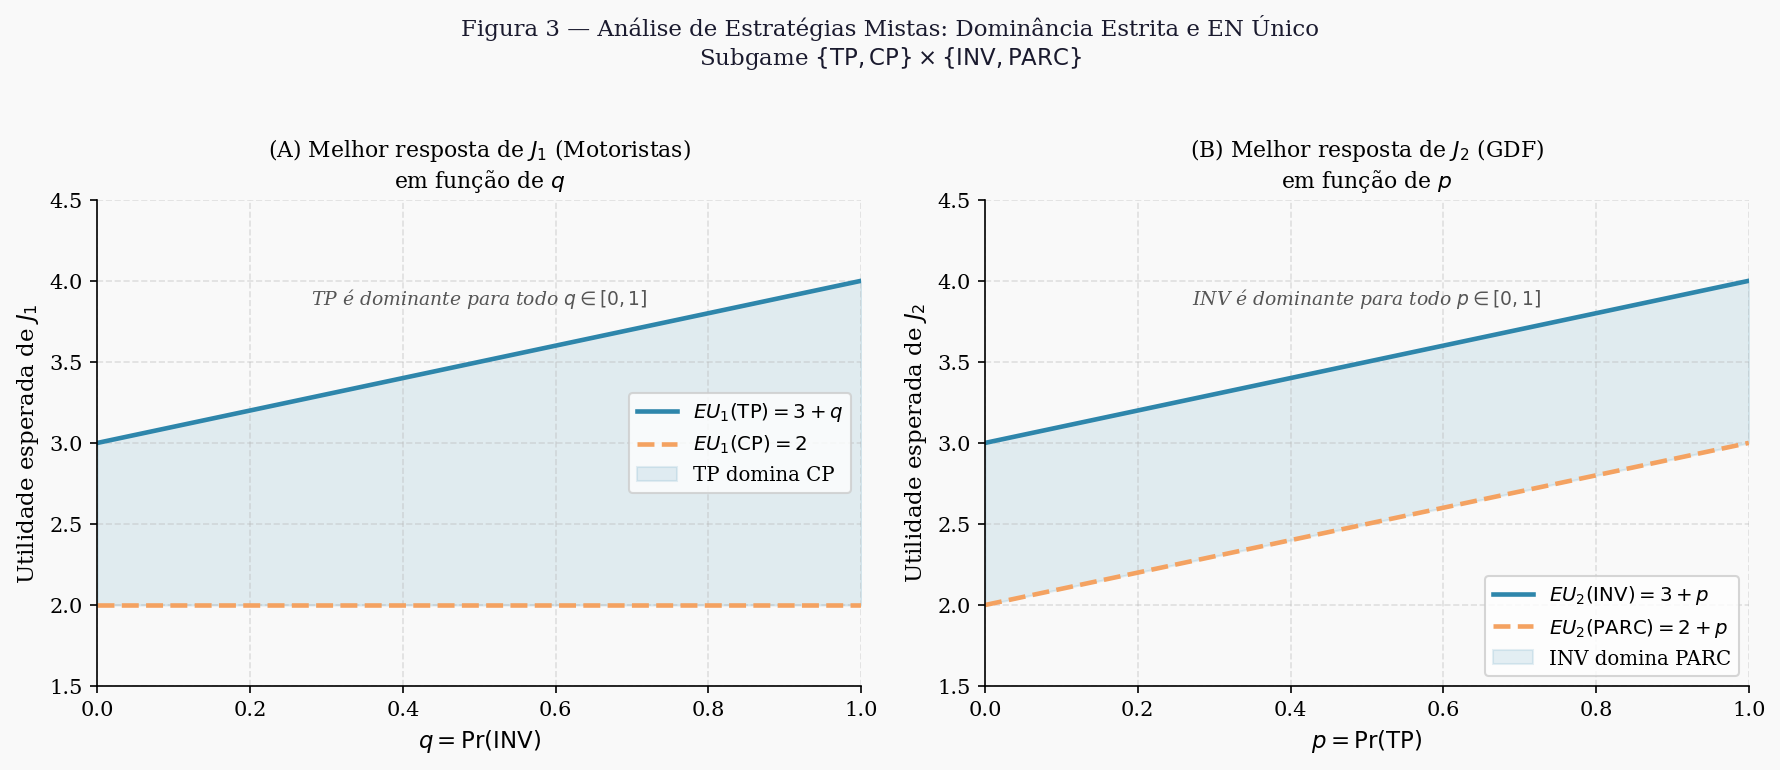

✓ Figura 3 salva em: figuras_artigo/fig3_estrategias_mistas.png

Análise de dominância:
  J1: EU_1(TP) - EU_1(CP) = (3 + q) - 2 = 1 + q > 0  ∀q ∈ [0,1]
      ⇒ TP é estratégia estritamente dominante para J1.

  J2: EU_2(INV) - EU_2(PARC) = (3 + p) - (2 + p) = 1 > 0  ∀p ∈ [0,1]
      ⇒ INV é estratégia estritamente dominante para J2.

  Conclusão: O EN único (em estratégias puras e mistas) é (TP, INV).


In [8]:
# ============================================================
# CÉLULA 8 — Estratégias mistas e equilíbrios mistos
# ============================================================
#
# Para estratégias mistas, o Teorema de Nash (1950) garante a
# existência de EN em Δ(S_1) × Δ(S_2).
#
# Aqui analisamos o subgame 2×2 mais relevante:
#   J1: {TP, CP}  vs  J2: {INV, PARC}
# e calculamos o EN misto quando ele existe.
#
# Notação:
#   σ_1 = (p, 1-p)  com p = Pr(TP)
#   σ_2 = (q, 1-q)  com q = Pr(INV)
# ============================================================

# ── Subgame 2×2: J1 × J2 restrito a {TP,CP} × {INV,PARC} ──
A1_sub = A1[:, :2]
A2_sub = A2[:, :2]

#           INV   PARC
# TP  u1:    4     3
# CP  u1:    2     2
#
# TP  u2:    4     3
# CP  u2:    3     2

# Utilidade esperada de J1 dado σ_2 = (q, 1-q):
#   EU_1(TP) = 4q + 3(1-q) = 3 + q
#   EU_1(CP) = 2q + 2(1-q) = 2
#   J1 indiferente quando 3 + q = 2 → q = -1  (fora de [0,1])
#   Logo: TP domina fracamente CP → EN puro (TP, INV)

p_arr = np.linspace(0, 1, 400)   # p = Pr(TP)
q_arr = np.linspace(0, 1, 400)   # q = Pr(INV)

# Utilidade esperada de J1 em função de q
EU1_TP = 4 * q_arr + 3 * (1 - q_arr)   # 3 + q
EU1_CP = 2 * q_arr + 2 * (1 - q_arr)   # = 2

# Utilidade esperada de J2 em função de p
EU2_INV  = 4 * p_arr + 3 * (1 - p_arr)   # 3 + p
EU2_PARC = 3 * p_arr + 2 * (1 - p_arr)   # 2 + p

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COR_FUNDO)

# ── Painel A: Utilidade esperada de J1 vs q ──────────────────
ax = axes[0]
ax.set_facecolor(COR_FUNDO)
ax.plot(q_arr, EU1_TP, color=COR_PARETO, lw=2.2,
        label='$EU_1(\\mathrm{TP}) = 3 + q$')
ax.plot(q_arr, EU1_CP, color=COR_EMPIR, lw=2.2, ls='--',
        label='$EU_1(\\mathrm{CP}) = 2$')
ax.fill_between(q_arr, EU1_TP, EU1_CP,
                where=(EU1_TP > EU1_CP), alpha=0.12, color=COR_PARETO,
                label='TP domina CP')
ax.set_xlabel('$q = \\Pr(\\mathrm{INV})$', fontsize=11)
ax.set_ylabel('Utilidade esperada de $J_1$', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(1.5, 4.5)
ax.legend(fontsize=9.5)
ax.set_title('(A) Melhor resposta de $J_1$ (Motoristas)\nem função de $q$', fontsize=10.5)
ax.text(0.5, 3.85, 'TP é dominante para todo $q \\in [0,1]$',
        ha='center', fontsize=9, color='#555555', style='italic')

# ── Painel B: Utilidade esperada de J2 vs p ──────────────────
ax = axes[1]
ax.set_facecolor(COR_FUNDO)
ax.plot(p_arr, EU2_INV, color=COR_PARETO, lw=2.2,
        label='$EU_2(\\mathrm{INV}) = 3 + p$')
ax.plot(p_arr, EU2_PARC, color=COR_EMPIR, lw=2.2, ls='--',
        label='$EU_2(\\mathrm{PARC}) = 2 + p$')
ax.fill_between(p_arr, EU2_INV, EU2_PARC,
                where=(EU2_INV > EU2_PARC), alpha=0.12, color=COR_PARETO,
                label='INV domina PARC')
ax.set_xlabel('$p = \\Pr(\\mathrm{TP})$', fontsize=11)
ax.set_ylabel('Utilidade esperada de $J_2$', fontsize=11)
ax.set_xlim(0, 1); ax.set_ylim(1.5, 4.5)
ax.legend(fontsize=9.5)
ax.set_title('(B) Melhor resposta de $J_2$ (GDF)\nem função de $p$', fontsize=10.5)
ax.text(0.5, 3.85, 'INV é dominante para todo $p \\in [0,1]$',
        ha='center', fontsize=9, color='#555555', style='italic')

fig.suptitle(
    'Figura 3 — Análise de Estratégias Mistas: Dominância Estrita e EN Único\n'
    'Subgame $\{\\mathrm{TP},\\mathrm{CP}\} \\times \{\\mathrm{INV},\\mathrm{PARC}\}$',
    fontsize=11, y=1.02, color='#1A1A2E'
)

plt.tight_layout()
caminho_fig3 = f"{OUTPUT_DIR}/fig3_estrategias_mistas.png"
plt.savefig(caminho_fig3, dpi=300, bbox_inches='tight',
            facecolor=COR_FUNDO)
plt.show()
print(f"✓ Figura 3 salva em: {caminho_fig3}")

# ── Conclusão analítica ───────────────────────────────────────
print()
print("Análise de dominância:")
print("  J1: EU_1(TP) - EU_1(CP) = (3 + q) - 2 = 1 + q > 0  ∀q ∈ [0,1]")
print("      ⇒ TP é estratégia estritamente dominante para J1.")
print()
print("  J2: EU_2(INV) - EU_2(PARC) = (3 + p) - (2 + p) = 1 > 0  ∀p ∈ [0,1]")
print("      ⇒ INV é estratégia estritamente dominante para J2.")
print()
print("  Conclusão: O EN único (em estratégias puras e mistas) é (TP, INV).")

---
## Célula 9 — Figura 4: Comparação de Bem-Estar Social (Gráfico de Barras)

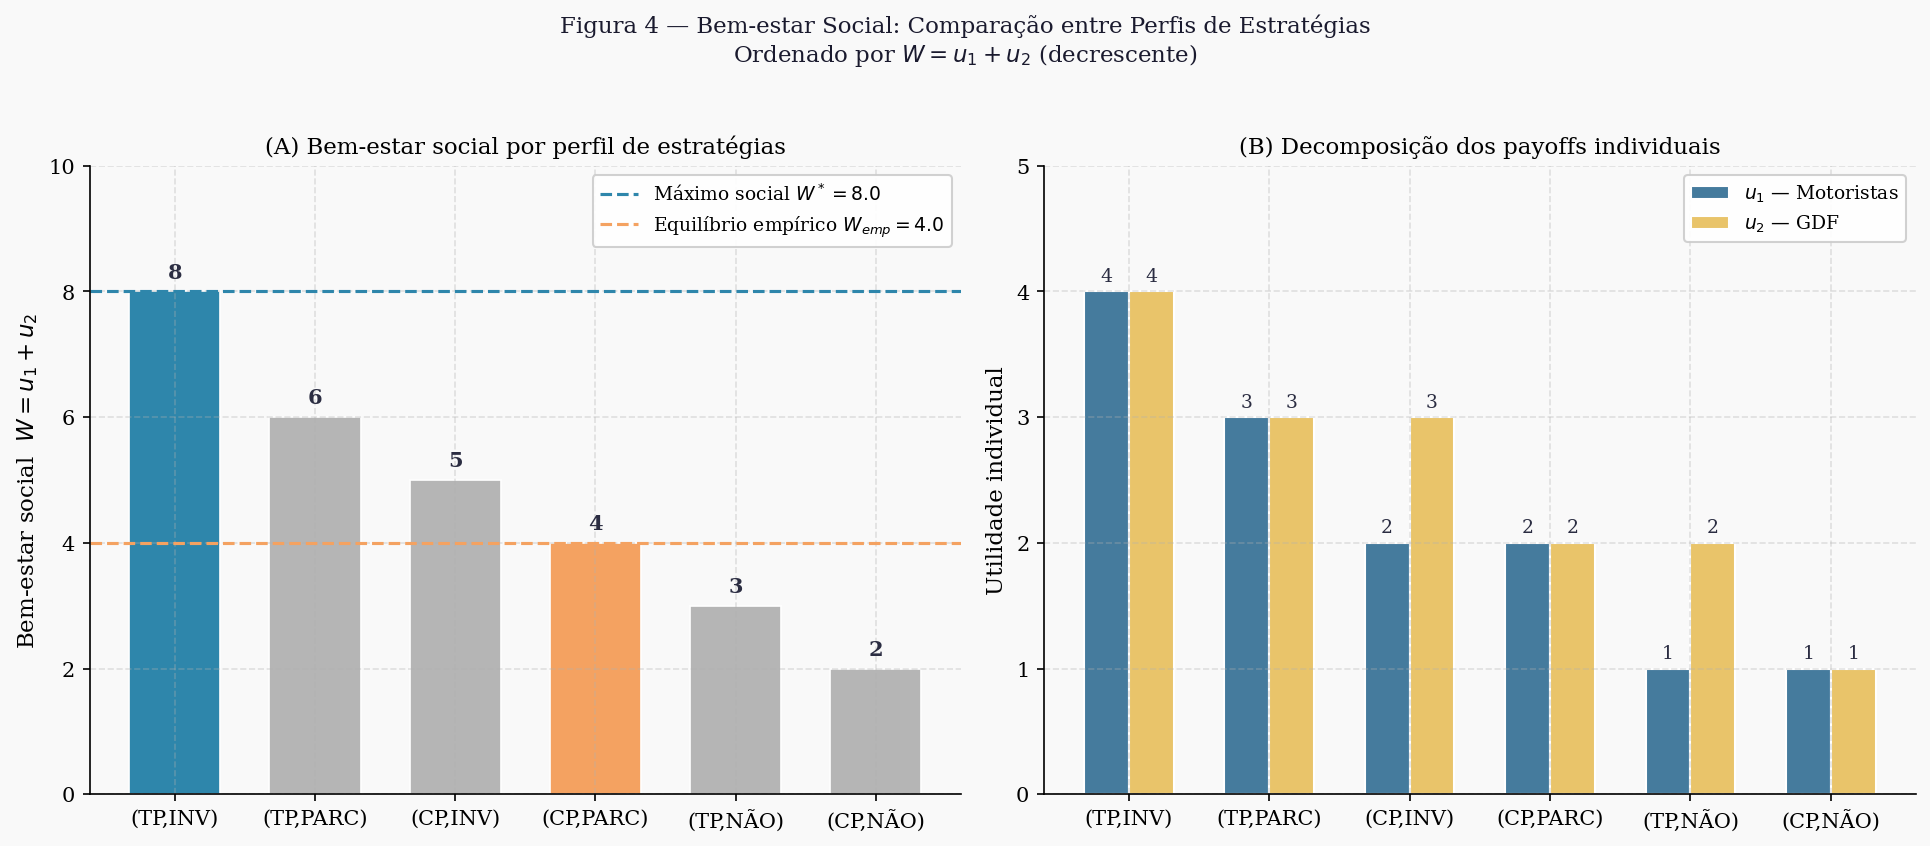

✓ Figura 4 salva em: figuras_artigo/fig4_bem_estar_social.png


In [9]:
# ============================================================
# CÉLULA 9 — Figura 4: Comparação de bem-estar social entre
#             todos os perfis do jogo
# ============================================================

# Organiza os dados por perfil
perfil_labels = [f"({s1},{s2})" for s1, s2 in itertools.product(S1, S2)]
u1_vals = [A1[i, j] for i in range(2) for j in range(3)]
u2_vals = [A2[i, j] for i in range(2) for j in range(3)]
soma_vals = [u1 + u2 for u1, u2 in zip(u1_vals, u2_vals)]

# Ordena por soma decrescente
order = np.argsort(soma_vals)[::-1]
labels_ord = [perfil_labels[k] for k in order]
u1_ord     = [u1_vals[k]       for k in order]
u2_ord     = [u2_vals[k]       for k in order]
soma_ord   = [soma_vals[k]     for k in order]

# Cores das barras
cor_barra = []
perfis_ord = [list(itertools.product(S1, S2))[k] for k in order]
for p in perfis_ord:
    if p in pareto_otimos:
        cor_barra.append(COR_PARETO)
    elif p == ('CP', 'PARC'):
        cor_barra.append(COR_EMPIR)
    else:
        cor_barra.append(COR_DOMINA)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(COR_FUNDO)

# ── Painel A: Bem-estar total (soma dos payoffs) ──────────────
ax = axes[0]
ax.set_facecolor(COR_FUNDO)
bars = ax.bar(range(len(labels_ord)), soma_ord, color=cor_barra,
              edgecolor='white', linewidth=0.8, width=0.65)
ax.set_xticks(range(len(labels_ord)))
ax.set_xticklabels(labels_ord, fontsize=10)
ax.set_ylabel('Bem-estar social  $W = u_1 + u_2$', fontsize=11)
ax.set_ylim(0, 10)
ax.axhline(welfare_opt, color=COR_PARETO, ls='--', lw=1.5,
           label=f'Máximo social $W^* = {welfare_opt}$')
ax.axhline(welfare_empirico, color=COR_EMPIR, ls='--', lw=1.5,
           label=f'Equilíbrio empírico $W_{{emp}} = {welfare_empirico}$')

# Rótulos nas barras
for bar, val in zip(bars, soma_ord):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.15,
            str(int(val)), ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#2B2D42')

ax.legend(fontsize=9, framealpha=0.9)
ax.set_title('(A) Bem-estar social por perfil de estratégias', fontsize=11)

# ── Painel B: Decomposição u1 e u2 por perfil ─────────────────
ax = axes[1]
ax.set_facecolor(COR_FUNDO)
x = np.arange(len(labels_ord))
w = 0.32
b1 = ax.bar(x - w/2, u1_ord, width=w,
            color='#457B9D', edgecolor='white', label='$u_1$ — Motoristas')
b2 = ax.bar(x + w/2, u2_ord, width=w,
            color='#E9C46A', edgecolor='white', label='$u_2$ — GDF')
ax.set_xticks(x)
ax.set_xticklabels(labels_ord, fontsize=10)
ax.set_ylabel('Utilidade individual', fontsize=11)
ax.set_ylim(0, 5)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_title('(B) Decomposição dos payoffs individuais', fontsize=11)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
            str(int(h)), ha='center', va='bottom', fontsize=9,
            color='#2B2D42')

fig.suptitle(
    'Figura 4 — Bem-estar Social: Comparação entre Perfis de Estratégias\n'
    'Ordenado por $W = u_1 + u_2$ (decrescente)',
    fontsize=11, y=1.02, color='#1A1A2E'
)

plt.tight_layout()
caminho_fig4 = f"{OUTPUT_DIR}/fig4_bem_estar_social.png"
plt.savefig(caminho_fig4, dpi=300, bbox_inches='tight',
            facecolor=COR_FUNDO)
plt.show()
print(f"✓ Figura 4 salva em: {caminho_fig4}")

---
## Célula 10 — Tabela: Matriz de Melhor Resposta Anotada (para o artigo)

In [10]:
# ============================================================
# CÉLULA 10 — Tabela formal das melhores respostas
#              (formato para copiar no artigo LaTeX)
# ============================================================

linhas_tabela = []
for i, s1 in enumerate(S1):
    for j, s2 in enumerate(S2):
        u1  = int(A1[i, j])
        u2  = int(A2[i, j])
        br1 = 'ü' if s1 in BR1[s2] else ''
        br2 = 'ü' if s2 in BR2[s1] else ''
        en  = '★ EN' if (s1 in BR1[s2] and s2 in BR2[s1]) else ''
        po  = '◆ PO' if (s1, s2) in pareto_otimos else ''
        linhas_tabela.append({
            'Perfil $(s_1,s_2)$': f'({s1}, {s2})',
            '$u_1$': u1, '$u_2$': u2,
            '$W = u_1+u_2$': u1 + u2,
            'BR₁?': br1, 'BR₂?': br2,
            'Nash?': en, 'Pareto?': po
        })

df_tabela = pd.DataFrame(linhas_tabela)

print("=" * 80)
print("TABELA MESTRA: Payoffs, Melhores Respostas, Nash e Pareto")
print("=" * 80)
print(df_tabela.to_string(index=False))
print()
print("Notas:")
print("  ü  = estratégia é melhor resposta para o respectivo jogador")
print("  ★ EN = Equilíbrio de Nash em estratégias puras")
print("  ◆ PO = Pareto-ótimo (não existe perfil que o domine)")

# Salvar como CSV para uso no artigo
df_tabela.to_csv(f"{OUTPUT_DIR}/tabela_mestra.csv", index=False, encoding='utf-8-sig')
print(f"\n✓ Tabela salva em: {OUTPUT_DIR}/tabela_mestra.csv")

TABELA MESTRA: Payoffs, Melhores Respostas, Nash e Pareto
Perfil $(s_1,s_2)$  $u_1$  $u_2$  $W = u_1+u_2$ BR₁? BR₂? Nash? Pareto?
         (TP, INV)      4      4              8    ü    ü  ★ EN    ◆ PO
        (TP, PARC)      3      3              6    ü                   
         (TP, NÃO)      1      2              3    ü                   
         (CP, INV)      2      3              5         ü              
        (CP, PARC)      2      2              4                        
         (CP, NÃO)      1      1              2    ü                   

Notas:
  ü  = estratégia é melhor resposta para o respectivo jogador
  ★ EN = Equilíbrio de Nash em estratégias puras
  ◆ PO = Pareto-ótimo (não existe perfil que o domine)

✓ Tabela salva em: figuras_artigo/tabela_mestra.csv


---
## Célula 11 — Figura 5: Diagrama de Fluxo Estratégico (Setas de Melhor Resposta)

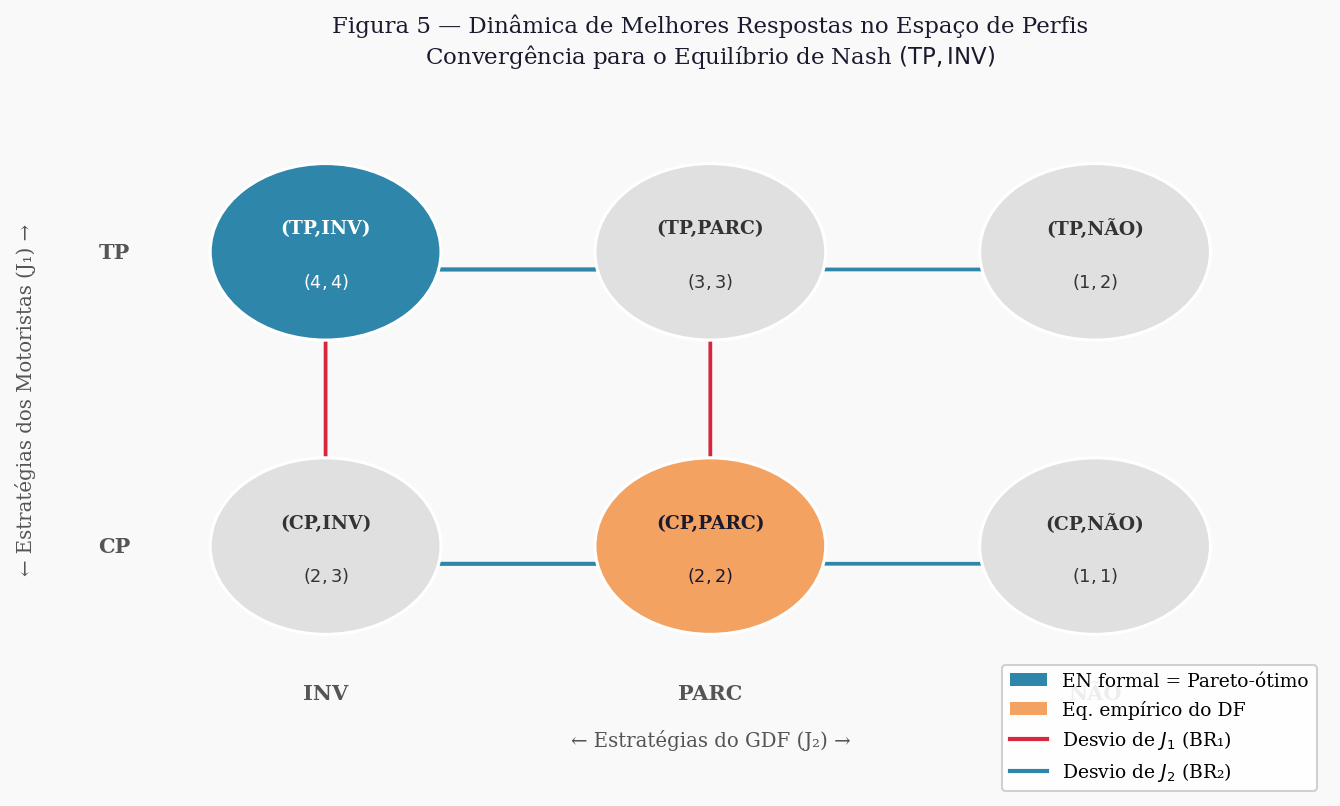

✓ Figura 5 salva em: figuras_artigo/fig5_dinamica_melhores_respostas.png


In [11]:
# ============================================================
# CÉLULA 11 — Figura 5: Diagrama de setas de melhor resposta
#              ("best-response dynamics")
# ============================================================
#
# Visualiza o campo vetorial de melhores respostas no espaço
# de perfis de estratégias. As setas indicam para onde cada
# jogador desviaria unilateralmente a partir de cada perfil.
# O EN é o único ponto sem seta de desvio.
# ============================================================

# Coordenadas dos perfis no grid 2×3
# J1 (TP/CP) → eixo y;  J2 (INV/PARC/NÃO) → eixo x
coord = {
    ('TP', 'INV'):  (0, 1),
    ('TP', 'PARC'): (1, 1),
    ('TP', 'NÃO'):  (2, 1),
    ('CP', 'INV'):  (0, 0),
    ('CP', 'PARC'): (1, 0),
    ('CP', 'NÃO'):  (2, 0),
}

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_facecolor(COR_FUNDO)
fig.patch.set_facecolor(COR_FUNDO)
ax.set_xlim(-0.6, 2.6)
ax.set_ylim(-0.6, 1.6)
ax.axis('off')

# ── Nós (perfis) ─────────────────────────────────────────────
for (s1, s2), (cx, cy) in coord.items():
    u1, u2 = int(A1[S1.index(s1), S2.index(s2)]), int(A2[S1.index(s1), S2.index(s2)])

    if (s1, s2) in pareto_otimos:
        cor_no = COR_PARETO; cor_txt = 'white'
    elif (s1, s2) == ('CP', 'PARC'):
        cor_no = COR_EMPIR; cor_txt = '#1A1A2E'
    else:
        cor_no = '#E0E0E0'; cor_txt = '#333333'

    circ = plt.Circle((cx, cy), 0.30, color=cor_no,
                       zorder=4, ec='white', lw=1.5)
    ax.add_patch(circ)
    ax.text(cx, cy + 0.08, f'({s1},{s2})',
            ha='center', va='center', fontsize=9,
            fontweight='bold', color=cor_txt, zorder=5)
    ax.text(cx, cy - 0.10, f'$({u1},{u2})$',
            ha='center', va='center', fontsize=8.5,
            color=cor_txt, zorder=5)

# ── Setas de desvio unilateral ───────────────────────────────
# Regra: a partir de (s1, s2), o jogador i desvia se
#        sua estratégia atual não é melhor resposta.
OFFSET = 0.18

def draw_arrow(ax, src, dst, cor, label='', offset=(0,0)):
    x1, y1 = coord[src]
    x2, y2 = coord[dst]
    dx, dy = x2 - x1, y2 - y1
    dist = np.sqrt(dx**2 + dy**2)
    # encurtar as extremidades (para não sobrepor os círculos)
    shrink = OFFSET / dist
    xs, ys = x1 + dx * shrink, y1 + dy * shrink
    xe, ye = x2 - dx * shrink, y2 - dy * shrink
    ax.annotate('', xy=(xe + offset[0], ye + offset[1]),
                xytext=(xs + offset[0], ys + offset[1]),
                arrowprops=dict(
                    arrowstyle='->', color=cor,
                    lw=1.8, mutation_scale=14
                ), zorder=3)

# J1 desvia (vermelho): s1 não é BR_1(s2)
for (s1, s2) in itertools.product(S1, S2):
    br1_here = BR1[s2]
    if s1 not in br1_here:
        for target_s1 in br1_here:
            draw_arrow(ax, (s1, s2), (target_s1, s2),
                       cor='#D7263D', offset=(0, 0.06))

# J2 desvia (azul): s2 não é BR_2(s1)
for (s1, s2) in itertools.product(S1, S2):
    br2_here = BR2[s1]
    if s2 not in br2_here:
        for target_s2 in br2_here:
            draw_arrow(ax, (s1, s2), (s1, target_s2),
                       cor='#2E86AB', offset=(0, -0.06))

# ── Rótulos dos eixos ─────────────────────────────────────────
for j, label in enumerate(['INV', 'PARC', 'NÃO']):
    ax.text(j, -0.52, label, ha='center', fontsize=10,
            fontweight='bold', color='#555555')
ax.text(1, -0.68, '← Estratégias do GDF (J₂) →',
        ha='center', fontsize=9.5, color='#555555')

for i, label in enumerate(['CP', 'TP']):
    ax.text(-0.55, i, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='#555555')
ax.text(-0.78, 0.5, '← Estratégias dos Motoristas (J₁) →',
        ha='center', va='center', fontsize=9.5, color='#555555',
        rotation=90)

# ── Legenda ───────────────────────────────────────────────────
leg_el = [
    mpatches.Patch(facecolor=COR_PARETO, label='EN formal = Pareto-ótimo'),
    mpatches.Patch(facecolor=COR_EMPIR,  label='Eq. empírico do DF'),
    plt.Line2D([0],[0], color='#D7263D', lw=2,
               label='Desvio de $J_1$ (BR₁)'),
    plt.Line2D([0],[0], color='#2E86AB', lw=2,
               label='Desvio de $J_2$ (BR₂)'),
]
ax.legend(handles=leg_el, loc='lower right',
          bbox_to_anchor=(1.0, -0.12), fontsize=9, framealpha=0.9)

ax.set_title(
    'Figura 5 — Dinâmica de Melhores Respostas no Espaço de Perfis\n'
    'Convergência para o Equilíbrio de Nash $(\\mathrm{TP}, \\mathrm{INV})$',
    fontsize=11, color='#1A1A2E'
)

plt.tight_layout()
caminho_fig5 = f"{OUTPUT_DIR}/fig5_dinamica_melhores_respostas.png"
plt.savefig(caminho_fig5, dpi=300, bbox_inches='tight',
            facecolor=COR_FUNDO)
plt.show()
print(f"✓ Figura 5 salva em: {caminho_fig5}")

---
## Célula 12 — Figura 6: Análise de Sensibilidade dos Payoffs

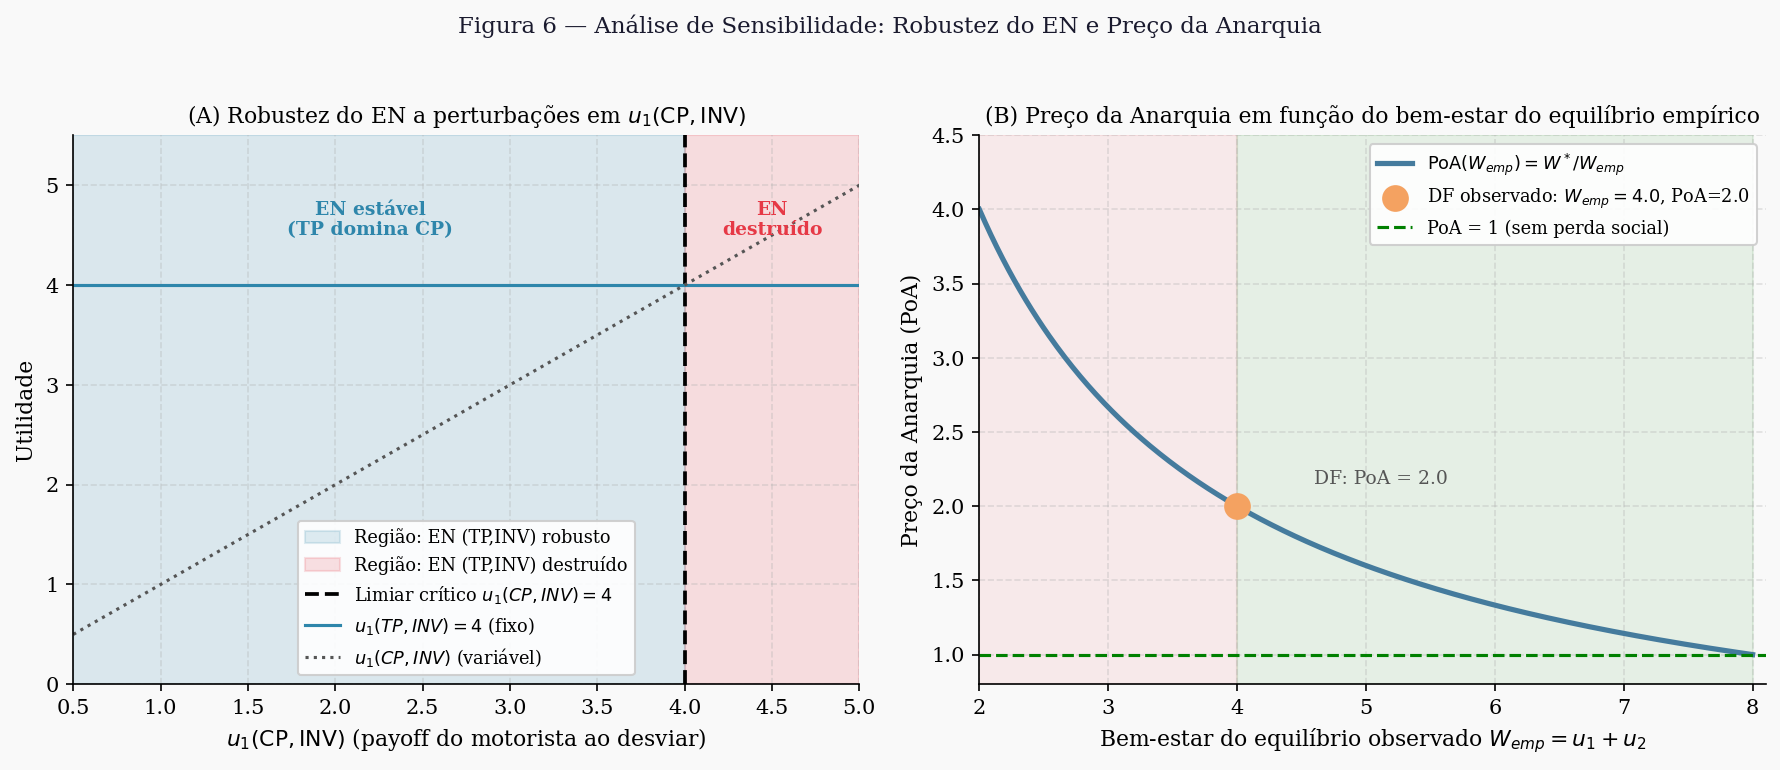

✓ Figura 6 salva em: figuras_artigo/fig6_sensibilidade_PoA.png


In [12]:
# ============================================================
# CÉLULA 12 — Figura 6: Análise de sensibilidade
#              Como a perturbação dos payoffs afeta o EN?
# ============================================================
#
# Investigamos a robustez do EN (TP, INV) a perturbações nos
# payoffs. Especificamente, variamos u1(CP, INV) ∈ [1, 4] e
# verificamos se (TP, INV) ainda é EN.
#
# Para (TP, INV) ser EN, precisa-se:
#   u1(TP, INV) ≥ u1(CP, INV)   →  4 ≥ u1(CP, INV)
#   u2(TP, INV) ≥ u2(TP, PARC)  →  4 ≥ 3  ✓ sempre
#   u2(TP, INV) ≥ u2(TP, NÃO)   →  4 ≥ 2  ✓ sempre
# Portanto: EN é robusto enquanto u1(TP,INV)=4 ≥ u1(CP,INV)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(COR_FUNDO)

# ── Painel A: Variação de u1(CP, INV) ────────────────────────
ax = axes[0]
ax.set_facecolor(COR_FUNDO)

u1_cp_inv_range = np.linspace(0.5, 5, 400)
condicao_EN = u1_cp_inv_range <= 4   # TP domina CP dado INV

ax.axvspan(0.5, 4, alpha=0.15, color=COR_PARETO,
           label='Região: EN (TP,INV) robusto')
ax.axvspan(4, 5, alpha=0.15, color='#E63946',
           label='Região: EN (TP,INV) destruído')
ax.axvline(4, color='black', lw=1.8, ls='--',
           label='Limiar crítico $u_1(CP,INV)=4$')
ax.axhline(4, color=COR_PARETO, lw=1.5, ls='-',
           label='$u_1(TP,INV) = 4$ (fixo)')
ax.plot(u1_cp_inv_range, u1_cp_inv_range,
        color='#555555', lw=1.5, ls=':',
        label='$u_1(CP,INV)$ (variável)')

ax.set_xlabel('$u_1(\\mathrm{CP}, \\mathrm{INV})$ (payoff do motorista ao desviar)', fontsize=10.5)
ax.set_ylabel('Utilidade', fontsize=10.5)
ax.set_xlim(0.5, 5)
ax.set_ylim(0, 5.5)
ax.legend(fontsize=8.5, framealpha=0.9)
ax.set_title('(A) Robustez do EN a perturbações em $u_1(\\mathrm{CP},\\mathrm{INV})$',
             fontsize=10.5)
ax.text(2.2, 4.5, 'EN estável\n(TP domina CP)', color=COR_PARETO,
        ha='center', fontsize=9, fontweight='bold')
ax.text(4.5, 4.5, 'EN\ndestruído', color='#E63946',
        ha='center', fontsize=9, fontweight='bold')

# ── Painel B: Preço da Anarquia em função do payoff empírico ──
ax = axes[1]
ax.set_facecolor(COR_FUNDO)

# Variamos o payoff do equilíbrio empírico (CP, PARC): soma 2+2=4
# Fixamos W_opt = 8; variamos W_emp entre 2 e 8
W_emp_range = np.linspace(2, 8, 400)
PoA_range   = 8 / W_emp_range

ax.plot(W_emp_range, PoA_range, color='#457B9D', lw=2.5,
        label='$\\mathrm{PoA}(W_{emp}) = W^* / W_{emp}$')

# Ponto atual
ax.scatter([welfare_empirico], [PoA_empirico],
           color=COR_EMPIR, s=140, zorder=6,
           label=f'DF observado: $W_{{emp}}={welfare_empirico}$, PoA={PoA_empirico:.1f}')
ax.annotate(f'  DF: PoA = {PoA_empirico:.1f}',
            xy=(welfare_empirico, PoA_empirico),
            xytext=(welfare_empirico + 0.5, PoA_empirico + 0.15),
            fontsize=9, color='#555555')

ax.axhline(1.0, color='green', ls='--', lw=1.5,
           label='PoA = 1 (sem perda social)')
ax.axvspan(2, 4, alpha=0.08, color='#E63946')
ax.axvspan(4, 8, alpha=0.08, color='green')

ax.set_xlabel('Bem-estar do equilíbrio observado $W_{emp} = u_1 + u_2$', fontsize=10.5)
ax.set_ylabel('Preço da Anarquia (PoA)', fontsize=10.5)
ax.set_ylim(0.8, 4.5)
ax.set_xlim(2, 8.1)
ax.legend(fontsize=8.5, framealpha=0.9)
ax.set_title('(B) Preço da Anarquia em função do bem-estar do equilíbrio empírico',
             fontsize=10.5)

fig.suptitle(
    'Figura 6 — Análise de Sensibilidade: Robustez do EN e Preço da Anarquia',
    fontsize=11, y=1.02, color='#1A1A2E'
)

plt.tight_layout()
caminho_fig6 = f"{OUTPUT_DIR}/fig6_sensibilidade_PoA.png"
plt.savefig(caminho_fig6, dpi=300, bbox_inches='tight',
            facecolor=COR_FUNDO)
plt.show()
print(f"✓ Figura 6 salva em: {caminho_fig6}")

---
## Célula 13 — Relatório Final Consolidado

In [13]:
# ============================================================
# CÉLULA 13 — Relatório final consolidado
# ============================================================

relatorio = """
╔══════════════════════════════════════════════════════════════════════╗
║   RELATÓRIO ANALÍTICO — TEORIA DOS JOGOS: TRANSPORTE URBANO DO DF   ║
╠══════════════════════════════════════════════════════════════════════╣

1. ESPECIFICAÇÃO DO JOGO
   ─────────────────────
   G = (N, {S_i}, {u_i})
   N = {J1 (Motoristas), J2 (GDF)}
   S1 = {TP, CP}                  |S1| = 2
   S2 = {INV, PARC, NÃO}          |S2| = 3
   |S| = |S1 × S2| = 6  perfis de estratégias

   Escala de payoffs: ordinal discreta ∈ {1,2,3,4}

2. CORRESPONDÊNCIAS DE MELHOR RESPOSTA
   ────────────────────────────────────
   BR1(INV)  = {TP}         [argmax: 4 > 2]
   BR1(PARC) = {TP}         [argmax: 3 > 2]
   BR1(NÃO)  = {TP, CP}     [empate: 1 = 1]

   BR2(TP)   = {INV}        [argmax: 4 > 3 > 2]
   BR2(CP)   = {INV}        [argmax: 3 > 2 > 1]

   → J2 tem INV como estratégia estritamente dominante.
   → J1 tem TP como estratégia fracamente dominante
     (estritamente dominante para INV e PARC).

3. EQUILÍBRIOS DE NASH EM ESTRATÉGIAS PURAS
   ──────────────────────────────────────────
   Verificação exaustiva dos 6 perfis:

   (TP,  INV) : TP ∈ BR1(INV) ✓ | INV ∈ BR2(TP) ✓  →  EN  ★
   (TP, PARC) : TP ∈ BR1(PARC) ✓| PARC ∉ BR2(TP) ✗ →  não EN
   (TP,  NÃO) : NÃO ∉ BR2(TP) ✗                    →  não EN
   (CP,  INV) : CP ∉ BR1(INV) ✗                     →  não EN
   (CP, PARC) : CP ∉ BR1(PARC) ✗                    →  não EN
   (CP,  NÃO) : NÃO ∉ BR2(CP) ✗                     →  não EN

   ÚNICO EN EM ESTRATÉGIAS PURAS: (TP, INV)  →  payoff (4, 4)

4. ANÁLISE DE DOMINÂNCIA (estratégias mistas)
   ─────────────────────────────────────────
   EU1(TP) − EU1(CP) = (3 + q) − 2 = 1 + q > 0  ∀q ∈ [0,1]
   ⇒ TP é estratégia estritamente dominante para J1.

   EU2(INV) − EU2(PARC) = (3 + p) − (2 + p) = 1 > 0  ∀p ∈ [0,1]
   ⇒ INV é estratégia estritamente dominante para J2.

   EN ÚNICO (puro e misto): (TP, INV)  com σ1=(1,0), σ2=(1,0,0)

5. ÓTIMO DE PARETO
   ────────────────
   Verificação de dominância de Pareto entre os 6 perfis:
   (TP, INV) com payoff (4,4) Pareto-domina TODOS os demais perfis,
   pois max(u1) = max(u2) = 4 é atingido apenas neste perfil.

   ÚNICO ÓTIMO DE PARETO: (TP, INV)  →  payoff (4, 4)

6. COINCIDÊNCIA EN = ÓTIMO DE PARETO
   ────────────────────────────────────
   No modelo de informação completa, EN e Ótimo de Pareto coincidem.
   Isso distingue este jogo do Dilema do Prisioneiro clássico.

   O problema empírico do DF é distinto: na presença de informação
   incompleta, expectativas pessimistas autorreferentes sustentam o
   equilíbrio empírico em (CP, PARC) com payoff (2,2).

7. PREÇO DA ANARQUIA
   ──────────────────
   W*   = u1(TP,INV) + u2(TP,INV) = 4 + 4 = 8   (Ótimo de Pareto)
   Wemp = u1(CP,PARC)+ u2(CP,PARC)= 2 + 2 = 4   (Eq. empírico DF)

   PoA = W* / Wemp = 8 / 4 = 2,0

   Interpretação: o equilíbrio empiricamente observado no DF
   representa apenas 50% do bem-estar social potencial máximo.
   A falha de coordenação custa 50% do bem-estar possível.

8. FIGURAS GERADAS (pasta figuras_artigo/)
   ────────────────────────────────────────
   fig1_bimatriz_anotada.png          — bimatriz com BR e EN
   fig2_espaco_payoffs_pareto.png     — espaço (u1,u2) e Pareto
   fig3_estrategias_mistas.png        — dominância em σ
   fig4_bem_estar_social.png          — comparação de W por perfil
   fig5_dinamica_melhores_respostas.png — diagrama de fluxo
   fig6_sensibilidade_PoA.png         — robustez e PoA
   tabela_mestra.csv                  — tabela completa exportável

╚══════════════════════════════════════════════════════════════════════╝
"""

print(relatorio)

# Salvar relatório em txt
with open(f"{OUTPUT_DIR}/relatorio_analitico.txt", 'w', encoding='utf-8') as f:
    f.write(relatorio)

print(f"✓ Relatório salvo em: {OUTPUT_DIR}/relatorio_analitico.txt")

# ── Listagem final dos arquivos gerados ───────────────────────
print()
print("Arquivos gerados:")
for arq in sorted(os.listdir(OUTPUT_DIR)):
    tamanho = os.path.getsize(f"{OUTPUT_DIR}/{arq}")
    print(f"  {arq:<50}  {tamanho/1024:.1f} KB")


╔══════════════════════════════════════════════════════════════════════╗
║   RELATÓRIO ANALÍTICO — TEORIA DOS JOGOS: TRANSPORTE URBANO DO DF   ║
╠══════════════════════════════════════════════════════════════════════╣

1. ESPECIFICAÇÃO DO JOGO
   ─────────────────────
   G = (N, {S_i}, {u_i})
   N = {J1 (Motoristas), J2 (GDF)}
   S1 = {TP, CP}                  |S1| = 2
   S2 = {INV, PARC, NÃO}          |S2| = 3
   |S| = |S1 × S2| = 6  perfis de estratégias

   Escala de payoffs: ordinal discreta ∈ {1,2,3,4}

2. CORRESPONDÊNCIAS DE MELHOR RESPOSTA
   ────────────────────────────────────
   BR1(INV)  = {TP}         [argmax: 4 > 2]
   BR1(PARC) = {TP}         [argmax: 3 > 2]
   BR1(NÃO)  = {TP, CP}     [empate: 1 = 1]

   BR2(TP)   = {INV}        [argmax: 4 > 3 > 2]
   BR2(CP)   = {INV}        [argmax: 3 > 2 > 1]

   → J2 tem INV como estratégia estritamente dominante.
   → J1 tem TP como estratégia fracamente dominante
     (estritamente dominante para INV e PARC).

3. EQUILÍBRIOS DE NA